In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file_path = "diabetes.csv"
df = pd.read_csv(file_path)

coords_cols = ["Glucose", "BMI", "Age"]
X = df[coords_cols].to_numpy(dtype=float)

mean = X.mean(axis=0)
std = X.std(axis=0)
std[std == 0] = 1.0
X_3d = (X - mean) / std

c1 = X_3d[0].copy()
d2 = np.sum((X_3d - c1) ** 2, axis=1)
c2 = X_3d[np.argmax(d2)].copy()
centers = np.vstack([c1, c2])

max_iter = 100
tol = 1e-6

for _ in range(max_iter):
    dist_to_c1 = np.sqrt(np.sum((X_3d - centers[0]) ** 2, axis=1))
    dist_to_c2 = np.sqrt(np.sum((X_3d - centers[1]) ** 2, axis=1))

    labels = (dist_to_c2 < dist_to_c1).astype(int)

    new_centers = centers.copy()
    for k in [0, 1]:
        pts = X_3d[labels == k]
        if len(pts) > 0:
            new_centers[k] = pts.mean(axis=0)

    if np.max(np.abs(new_centers - centers)) < tol:
        centers = new_centers
        break

    centers = new_centers

df["Cluster"] = labels + 1

cluster_counts = df["Cluster"].value_counts().sort_index()
cluster_counts_table = cluster_counts.rename_axis("Cluster").reset_index(name="Count")

comparison_table = pd.crosstab(df["Cluster"], df["Outcome"], rownames=["Cluster"], colnames=["Outcome"])

centers_table = pd.DataFrame(centers, columns=["x", "y", "z"])
centers_table.index = centers_table.index + 1
centers_table.index.name = "Cluster"

df.to_csv("diabetes_with_clusters.csv", index=False)

print("Использованные координаты:", coords_cols)
print("Центры кластеров (x, y, z):")
display(centers_table)

print("Количество точек в кластерах:")
display(cluster_counts_table)

print("Сравнение Cluster vs Outcome:")
display(comparison_table)

print("Файл сохранен: diabetes_with_clusters.csv")

Использованные координаты: ['Glucose', 'BMI', 'Age']
Центры кластеров (x, y, z):


,x,y,z
Cluster,,,
1,0.797092,0.417681,0.773937
2,-0.519395,-0.272166,-0.504307


Количество точек в кластерах:


,Cluster,Count
0,1,303
1,2,465


Сравнение Cluster vs Outcome:


Outcome,0,1
Cluster,,
1,115,188
2,385,80


Файл сохранен: diabetes_with_clusters.csv


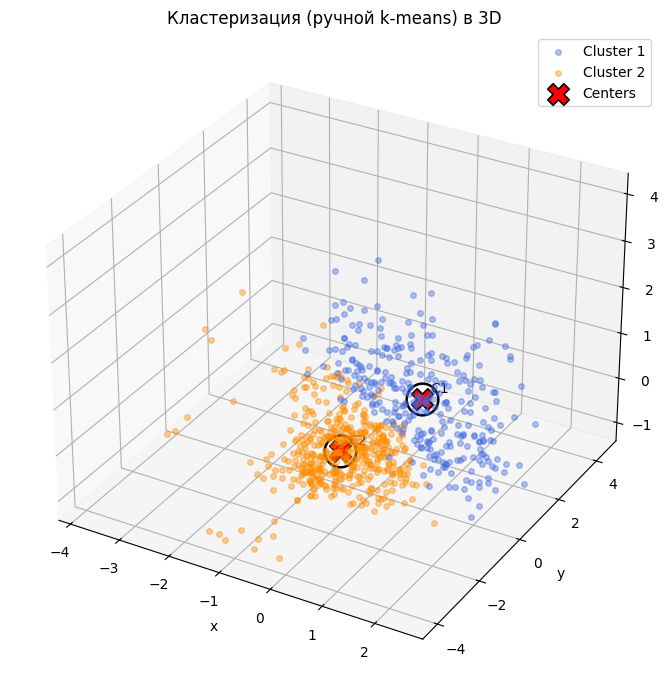

In [3]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

mask1 = labels == 0
mask2 = labels == 1

ax.scatter(
    X_3d[mask1, 0], X_3d[mask1, 1], X_3d[mask1, 2],
    s=16, alpha=0.40, c="royalblue", label="Cluster 1", depthshade=False
)
ax.scatter(
    X_3d[mask2, 0], X_3d[mask2, 1], X_3d[mask2, 2],
    s=16, alpha=0.40, c="darkorange", label="Cluster 2", depthshade=False
)

ax.scatter(
    centers[:, 0], centers[:, 1], centers[:, 2],
    s=520, c="white", marker="o", edgecolors="black", linewidths=1.8,
    depthshade=False
)
ax.scatter(
    centers[:, 0], centers[:, 1], centers[:, 2],
    s=240, c="red", marker="X", edgecolors="black", linewidths=1.2,
    depthshade=False, label="Centers"
)

for i, (cx, cy, cz) in enumerate(centers, start=1):
    ax.text(cx + 0.12, cy + 0.12, cz + 0.12, f"C{i}", color="black", fontsize=10)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Кластеризация (ручной k-means) в 3D")
ax.legend()
plt.tight_layout()
plt.show()